## 1. Data Load & Analysis

In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
import statsmodels.api as sm
from sklearn.utils import resample
import pickle
import os

In [176]:
df = pd.read_csv("bmw_global_sales_dataset.csv")
print(df.shape)
print(df.info())

(1000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   1000 non-null   int64  
 1   month                  1000 non-null   int64  
 2   country                1000 non-null   object 
 3   model                  1000 non-null   object 
 4   segment                1000 non-null   object 
 5   engine_type            1000 non-null   object 
 6   price_usd              1000 non-null   int64  
 7   marketing_spend_usd    1000 non-null   int64  
 8   dealership_count       1000 non-null   int64  
 9   fuel_price_usd         1000 non-null   float64
 10  gdp_growth_percent     1000 non-null   float64
 11  interest_rate_percent  1000 non-null   float64
 12  competition_index      1000 non-null   int64  
 13  units_sold             1000 non-null   int64  
dtypes: float64(3), int64(7), object(4)
memory usag

In [177]:
df.head()

,year,month,country,model,segment,engine_type,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,units_sold
0,2021,1,Australia,X1,SUV,Petrol,82234,315372,96,0.97,6.29,1.2,8,324
1,2018,8,Australia,i4,Sedan,Electric,82291,447798,234,0.97,6.29,1.2,7,556
2,2022,12,USA,5 Series,Electric,Hybrid,40594,259755,25,0.97,6.29,1.2,7,152
3,2019,11,Australia,i7,SUV,Electric,42371,323541,319,0.97,6.29,1.2,5,730
4,2021,12,Brazil,X5,SUV,Diesel,82315,482015,367,0.97,6.29,1.2,2,1156


## 2. Resampling Methods

In [178]:
X_1 = df[['marketing_spend_usd']].values
y_1 = df['units_sold'].values

In [179]:
degrees = np.arange(1, 10)
# arrays to hold average MSE across degrees
mse_k5, mse_k10, mse_loo, mse_boot = [], [], [], []

# resampling hyper-parameters
n_bootstraps = 100
n_repeats = 15  # number of different 5-fold CV repetitions

# store all repeated 5-fold curves: shape (len(degrees), n_repeats)
mse_k5_repeats = []

/Users/javidalakbarli/Downloads/ML_PR_3/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/javidalakbarli/Downloads/ML_PR_3/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/javidalakbarli/Downloads/ML_PR_3/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/javidalakbarli/Downloads/ML_PR_3/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/javidalakbarli/Downloads/ML_PR_3/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/javidalakba

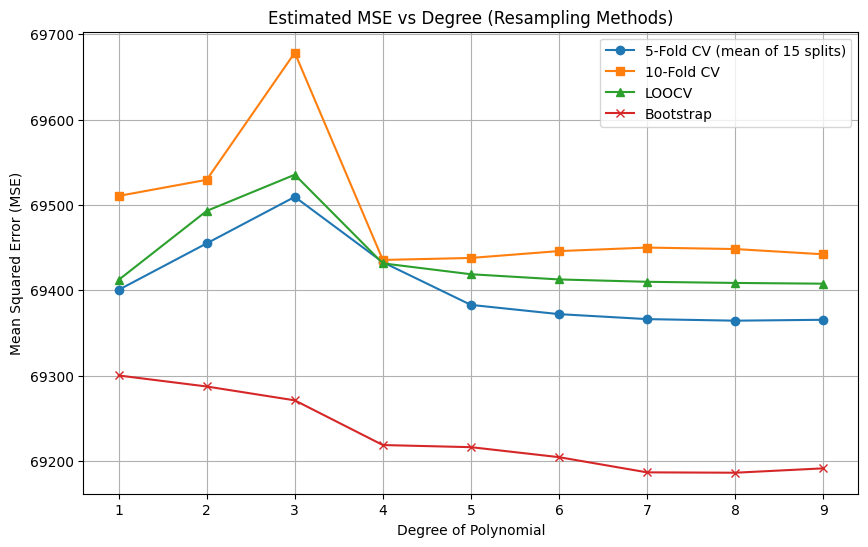

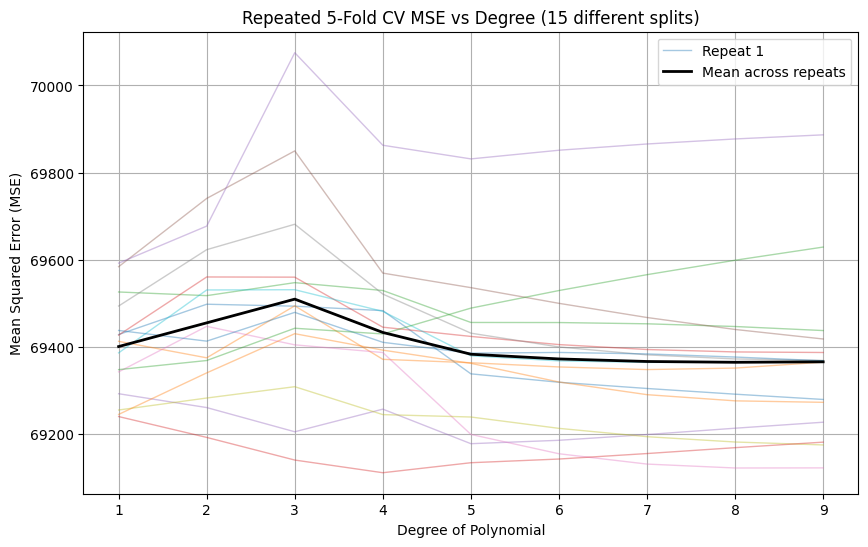

In [180]:
os.makedirs('images', exist_ok=True)

for d in degrees:
    poly = PolynomialFeatures(degree=d)

    # estimated MSE curves on full data
    X_poly_full = poly.fit_transform(X_1)
    model = LinearRegression()

    # repeated 5-fold CV with different splits
    k5_vals = []
    for r in range(n_repeats):
        kf = KFold(5, shuffle=True, random_state=42 + r)
        k5_vals.append(-cross_val_score(model, X_poly_full, y_1, scoring='neg_mean_squared_error', cv=kf).mean())
    mse_k5.append(np.mean(k5_vals))
    mse_k5_repeats.append(k5_vals)

    # single 10-fold CV
    mse_k10.append(-cross_val_score(model, X_poly_full, y_1, scoring='neg_mean_squared_error', cv=KFold(10, shuffle=True, random_state=42)).mean())

    # single LOOCV on full data
    mse_loo.append(-cross_val_score(model, X_poly_full, y_1, scoring='neg_mean_squared_error', cv=LeaveOneOut()).mean())

    # Bootstrap (train on bootstrap sample, evaluate on full data)
    boot_mses = []
    for _ in range(n_bootstraps):
        X_res, y_res = resample(X_poly_full, y_1)
        model.fit(X_res, y_res)
        boot_mses.append(mean_squared_error(y_1, model.predict(X_poly_full)))
    mse_boot.append(np.mean(boot_mses))

# Plot 1: 5-fold CV, 10-fold CV, LOOCV, and Bootstrap
plt.figure(figsize=(10, 6))
plt.plot(degrees, mse_k5, marker='o', label='5-Fold CV (mean of 15 splits)')
plt.plot(degrees, mse_k10, marker='s', label='10-Fold CV')
plt.plot(degrees, mse_loo, marker='^', label='LOOCV')
plt.plot(degrees, mse_boot, marker='x', label='Bootstrap')
plt.xlabel('Degree of Polynomial')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Estimated MSE vs Degree (Resampling Methods)')
plt.legend()
plt.grid(True)
plt.savefig('images/resampling_poly.png')

# Plot 2: All repeated 5-fold curves to visualise variability
mse_k5_repeats = np.array(mse_k5_repeats)  # shape (len(degrees), n_repeats)
plt.figure(figsize=(10, 6))
for r in range(n_repeats):
    plt.plot(degrees, mse_k5_repeats[:, r], alpha=0.4, linewidth=1, label=f'Repeat {r+1}' if r == 0 else None)
plt.plot(degrees, mse_k5, color='black', linewidth=2, label='Mean across repeats')
plt.xlabel('Degree of Polynomial')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Repeated 5-Fold CV MSE vs Degree (15 different splits)')
plt.legend()
plt.grid(True)
plt.savefig('images/resampling_poly_k5_repeats.png')

## 3. Model Selection

In [181]:
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop('units_sold', axis=1)
y = df_encoded['units_sold']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

### 3.1 Subset Selection (Forward Stepwise)

In [182]:
def forward_selection(X, y):
    """
    Greedy forward stepwise selection driven by AIC.

    At each step every remaining feature is tried; the one that
    produces the lowest AIC is permanently added to the active set.
    This continues until all features have been added, recording
    AIC / BIC / Adj-R² at each step so we can plot the full curve.

    The returned best_model and best_features correspond to the step
    where the GLOBAL minimum AIC is achieved — i.e. the optimal
    model size according to AIC.
    """
    initial_features = X.columns.tolist()
    selected_features = []          # features added so far, in order
    step_models = []                # OLS model at each step
    step_features = []              # feature list at each step
    aic_list, bic_list, adj_r2_list = [], [], []

    while len(initial_features) > len(selected_features):
        remaining = list(set(initial_features) - set(selected_features))
        best_aic, best_step_features, best_step_model = np.inf, None, None

        for new_col in remaining:
            features = selected_features + [new_col]
            X_sm = sm.add_constant(X[features])
            model = sm.OLS(y, X_sm).fit()
            if model.aic < best_aic:
                best_aic = model.aic
                best_step_features = features
                best_step_model = model

        selected_features = best_step_features
        step_models.append(best_step_model)
        step_features.append(best_step_features[:])
        aic_list.append(best_step_model.aic)
        bic_list.append(best_step_model.bic)
        adj_r2_list.append(best_step_model.rsquared_adj)

    # Pick the step with the globally lowest AIC as the best model
    best_idx = int(np.argmin(aic_list))
    best_model = step_models[best_idx]
    best_features = step_features[best_idx]

    return aic_list, bic_list, adj_r2_list, best_model, best_features

aic_list, bic_list, adj_r2_list, best_model, best_features = forward_selection(X_scaled, y)
num_predictors = np.arange(1, len(aic_list) + 1)
print(f"Optimal number of predictors (min AIC): {len(best_features)}")
print(f"Best features: {best_features}")

Optimal number of predictors (min AIC): 9
Best features: ['dealership_count', 'marketing_spend_usd', 'country_India', 'price_usd', 'country_China', 'competition_index', 'country_France', 'gdp_growth_percent', 'model_5 Series']


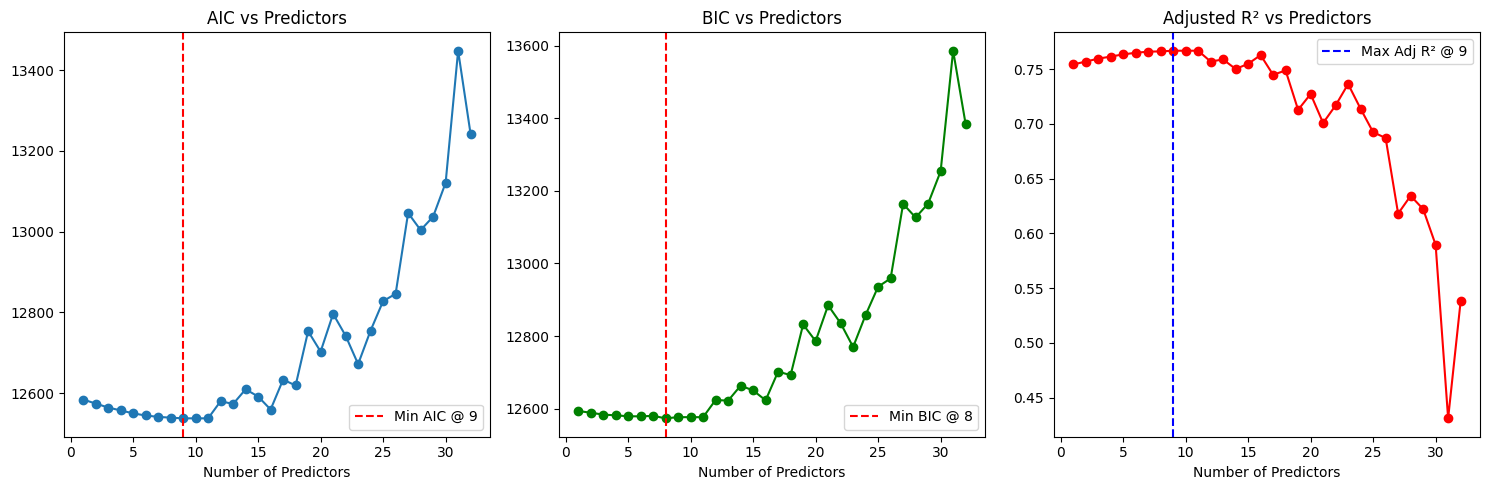

In [183]:
best_aic_n  = num_predictors[np.argmin(aic_list)]
best_bic_n  = num_predictors[np.argmin(bic_list)]
best_adjr2_n = num_predictors[np.argmax(adj_r2_list)]

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].plot(num_predictors, aic_list, marker='o')
axs[0].axvline(best_aic_n, color='red', linestyle='--', label=f'Min AIC @ {best_aic_n}')
axs[0].legend()
axs[0].set_xlabel('Number of Predictors')
axs[0].set_title('AIC vs Predictors')

axs[1].plot(num_predictors, bic_list, marker='o', color='g')
axs[1].axvline(best_bic_n, color='red', linestyle='--', label=f'Min BIC @ {best_bic_n}')
axs[1].legend()
axs[1].set_xlabel('Number of Predictors')
axs[1].set_title('BIC vs Predictors')

axs[2].plot(num_predictors, adj_r2_list, marker='o', color='r')
axs[2].axvline(best_adjr2_n, color='blue', linestyle='--', label=f'Max Adj R² @ {best_adjr2_n}')
axs[2].legend()
axs[2].set_xlabel('Number of Predictors')
axs[2].set_title('Adjusted R² vs Predictors')

plt.tight_layout()
plt.savefig('images/subset_selection.png')

## 3.2 Shrinkage Methods (Ridge and Lasso)

/Users/javidalakbarli/Downloads/ML_PR_3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/javidalakbarli/Downloads/ML_PR_3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/javidalakbarli/Downloads/ML_PR_3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/javidalakbarli/Downloads/ML_PR_3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/javidalakbarli/Downloads/ML_PR_3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/javidalakbarli/Downloads/ML_PR_3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  

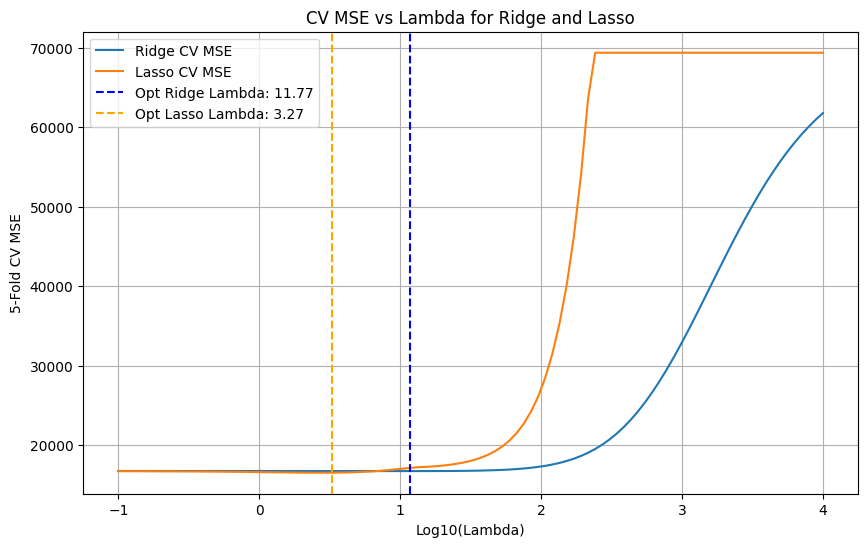

In [184]:
alphas = np.logspace(-1, 4, 100)

ridge_cv = RidgeCV(alphas=alphas, store_cv_results=True).fit(X_scaled, y)
lasso_cv = LassoCV(alphas=alphas, cv=10, random_state=42).fit(X_scaled, y)

ridge_mses = [-cross_val_score(Ridge(alpha=a), X_scaled, y, scoring='neg_mean_squared_error', cv=5).mean() for a in alphas]
lasso_mses = [-cross_val_score(Lasso(alpha=a), X_scaled, y, scoring='neg_mean_squared_error', cv=5).mean() for a in alphas]

plt.figure(figsize=(10, 6))
plt.plot(np.log10(alphas), ridge_mses, label='Ridge CV MSE')
plt.plot(np.log10(alphas), lasso_mses, label='Lasso CV MSE')
plt.axvline(np.log10(ridge_cv.alpha_), color='blue', linestyle='--', label=f'Opt Ridge Lambda: {ridge_cv.alpha_:.2f}')
plt.axvline(np.log10(lasso_cv.alpha_), color='orange', linestyle='--', label=f'Opt Lasso Lambda: {lasso_cv.alpha_:.2f}')
plt.xlabel('Log10(Lambda)')
plt.ylabel('5-Fold CV MSE')
plt.title('CV MSE vs Lambda for Ridge and Lasso')
plt.legend()
plt.grid(True)
plt.savefig('images/shrinkage.png')

## 3.3 PCA and PLS

/Users/javidalakbarli/Downloads/ML_PR_3/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/javidalakbarli/Downloads/ML_PR_3/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/javidalakbarli/Downloads/ML_PR_3/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/javidalakbarli/Downloads/ML_PR_3/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/javidalakbarli/Downloads/ML_PR_3/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/javidalakbarli/Downloads/ML_PR_3/.venv/lib/python3.9/site-packages/skl

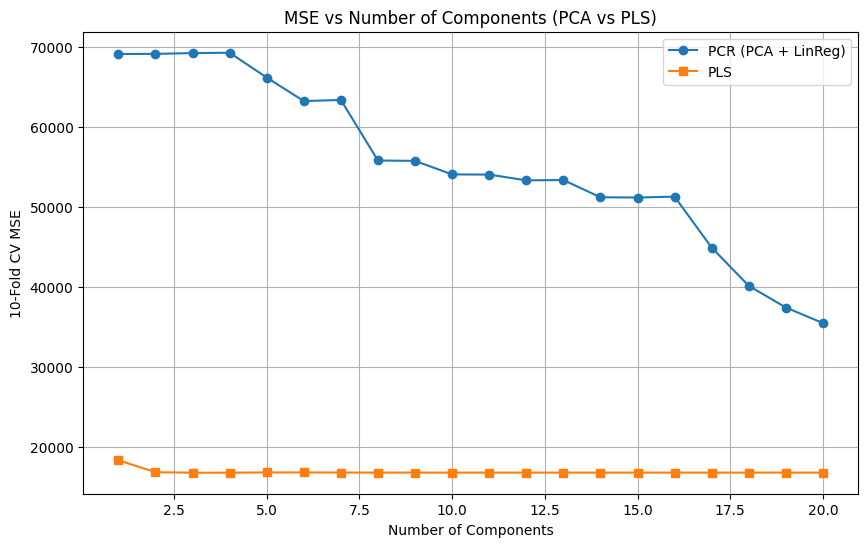

In [185]:
pca_mses, pls_mses = [], []
max_comp = min(X_scaled.shape[1], 20)
components = np.arange(1, max_comp + 1)
kf10 = KFold(n_splits=10, shuffle=True, random_state=42)

for c in components:
    # PCR
    X_pca = PCA(n_components=c).fit_transform(X_scaled)
    pca_mses.append(-cross_val_score(LinearRegression(), X_pca, y, scoring='neg_mean_squared_error', cv=kf10).mean())
    # PLS
    pls_mses.append(-cross_val_score(PLSRegression(n_components=c), X_scaled, y, scoring='neg_mean_squared_error', cv=kf10).mean())

plt.figure(figsize=(10, 6))
plt.plot(components, pca_mses, marker='o', label='PCR (PCA + LinReg)')
plt.plot(components, pls_mses, marker='s', label='PLS')
plt.xlabel('Number of Components')
plt.ylabel('10-Fold CV MSE')
plt.title('MSE vs Number of Components (PCA vs PLS)')
plt.legend()
plt.grid(True)
plt.savefig('images/pca_pls.png')

## 4. Save Models

In [186]:
# Create models directory for pickle files (used by Streamlit app)
os.makedirs("models", exist_ok=True)

# Save scaler (needed to transform new data the same way)
with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save Ridge and Lasso fitted models
with open("models/ridge_model.pkl", "wb") as f:
    pickle.dump(ridge_cv, f)
with open("models/lasso_model.pkl", "wb") as f:
    pickle.dump(lasso_cv, f)

# Save OLS best model and selected feature names (for prediction with same features)
with open("models/ols_best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
with open("models/best_features.pkl", "wb") as f:
    pickle.dump(best_features, f)

# Save full feature column list so Streamlit can build identical encoding (get_dummies order)
with open("models/feature_columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

# Save plot data for Streamlit visualizations (Ridge/Lasso, model selection, PCA/PLS)
plot_data = {
    "alphas": alphas,
    "ridge_mses": ridge_mses,
    "lasso_mses": lasso_mses,
    "ridge_opt_alpha": ridge_cv.alpha_,
    "lasso_opt_alpha": lasso_cv.alpha_,
    "num_predictors": num_predictors,
    "aic_list": aic_list,
    "bic_list": bic_list,
    "adj_r2_list": adj_r2_list,
    "components": components,
    "pca_mses": pca_mses,
    "pls_mses": pls_mses,
}
with open("models/plot_data.pkl", "wb") as f:
    pickle.dump(plot_data, f)

print("Saved: models/scaler.pkl, ridge_model.pkl, lasso_model.pkl, ols_best_model.pkl, best_features.pkl, feature_columns.pkl, plot_data.pkl")

Saved: models/scaler.pkl, ridge_model.pkl, lasso_model.pkl, ols_best_model.pkl, best_features.pkl, feature_columns.pkl, plot_data.pkl
